# Рубежный контроль №2 (весна 2025 года)
**Студент:** Ступницкий Михаил Сергеевич

**Группа:** ИУ5-64Б

|Номер задания|Метод №1|Метод №2|
|:---:|:---:|:---:|
|15|Линейная/логистическая регрессия|Градиентный бустинг|

**Задание**  
Для заданного набора данных (по Вашему варианту) постройте модели классификации или регрессии (в зависимости от конкретной задачи, рассматриваемой в наборе данных). Для построения моделей используйте методы 1 и 2 (по варианту для Вашей группы). Оцените качество моделей на основе подходящих метрик качества (не менее двух метрик). Какие метрики качества Вы использовали и почему? Какие выводы Вы можете сделать о качестве построенных моделей? Для построения моделей необходимо выполнить требуемую предобработку данных: заполнение пропусков, кодирование категориальных признаков, и т.д.

**Датасет**
https://www.kaggle.com/noriuk/us-education-datasets-unification-project (файл states_all_extended.csv)

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

from sklearn.metrics import (
    
    mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
)

In [3]:
df = pd.read_csv('states_all_extended.csv')

df.head(10)

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,G08_HI_A_READING,G08_HI_A_MATHEMATICS,G08_AS_A_READING,G08_AS_A_MATHEMATICS,G08_AM_A_READING,G08_AM_A_MATHEMATICS,G08_HP_A_READING,G08_HP_A_MATHEMATICS,G08_TR_A_READING,G08_TR_A_MATHEMATICS
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1992_COLORADO,COLORADO,1992,NaN,3185173.0,163253.0,1307986.0,1713934.0,3264826.0,1642466.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1992_CONNECTICUT,CONNECTICUT,1992,NaN,3834302.0,143542.0,1342539.0,2348221.0,3721338.0,2148041.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1992_DELAWARE,DELAWARE,1992,NaN,645233.0,45945.0,420942.0,178346.0,638784.0,372722.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1992_DISTRICT_OF_COLUMBIA,DISTRICT_OF_COLUMBIA,1992,NaN,709480.0,64749.0,0.0,644731.0,742893.0,329160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1992_FLORIDA,FLORIDA,1992,NaN,11506299.0,788420.0,5683949.0,5033930.0,11305642.0,5166374.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
data = df[['STATE', 'YEAR','TOTAL_REVENUE', 'FEDERAL_REVENUE', 'STATE_REVENUE', 'LOCAL_REVENUE',

'TOTAL_EXPENDITURE', 'INSTRUCTION_EXPENDITURE', 'SUPPORT_SERVICES_EXPENDITURE',

'CAPITAL_OUTLAY_EXPENDITURE', 'ENROLL', 'G04_A_A', 'G04_A_A_MATHEMATICS']]

data.head(10)

,STATE,YEAR,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,SUPPORT_SERVICES_EXPENDITURE,CAPITAL_OUTLAY_EXPENDITURE,ENROLL,G04_A_A,G04_A_A_MATHEMATICS
0,ALABAMA,1992,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,735036.0,174053.0,NaN,57948.0,208.0
1,ALASKA,1992,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,350902.0,37451.0,NaN,9748.0,NaN
2,ARIZONA,1992,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,1007732.0,609114.0,NaN,55433.0,215.0
3,ARKANSAS,1992,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,483488.0,145212.0,NaN,34632.0,210.0
4,CALIFORNIA,1992,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,8520926.0,2044688.0,NaN,418418.0,208.0
5,COLORADO,1992,3185173.0,163253.0,1307986.0,1713934.0,3264826.0,1642466.0,1035970.0,364760.0,NaN,50648.0,221.0
6,CONNECTICUT,1992,3834302.0,143542.0,1342539.0,2348221.0,3721338.0,2148041.0,1142600.0,48542.0,NaN,38058.0,227.0
7,DELAWARE,1992,645233.0,45945.0,420942.0,178346.0,638784.0,372722.0,194915.0,30595.0,NaN,8272.0,218.0
8,DISTRICT_OF_COLUMBIA,1992,709480.0,64749.0,0.0,644731.0,742893.0,329160.0,316679.0,47272.0,NaN,5832.0,193.0
9,FLORIDA,1992,11506299.0,788420.0,5683949.0,5033930.0,11305642.0,5166374.0,3410440.0,1667826.0,NaN,164416.0,214.0


In [17]:
data.dtypes

STATE                            object
YEAR                              int64
TOTAL_REVENUE                   float64
FEDERAL_REVENUE                 float64
STATE_REVENUE                   float64
LOCAL_REVENUE                   float64
TOTAL_EXPENDITURE               float64
INSTRUCTION_EXPENDITURE         float64
SUPPORT_SERVICES_EXPENDITURE    float64
CAPITAL_OUTLAY_EXPENDITURE      float64
ENROLL                          float64
G04_A_A                         float64
G04_A_A_MATHEMATICS             float64
dtype: object

In [18]:
# Список признаков
features = [
    'STATE',
    'YEAR',
    'TOTAL_REVENUE',
    'FEDERAL_REVENUE',
    'STATE_REVENUE',
    'LOCAL_REVENUE',
    'TOTAL_EXPENDITURE',
    'INSTRUCTION_EXPENDITURE',
    'SUPPORT_SERVICES_EXPENDITURE',
    'CAPITAL_OUTLAY_EXPENDITURE',
    'ENROLL',
    'G04_A_A'
]

In [21]:
data.shape

(1715, 13)

Для выполнения работы оставим только те строки, в которых значение целевой переменной GO4_A_A_MATHEMATICS 
не null

In [20]:
data.isnull().sum()

STATE                              0
YEAR                               0
TOTAL_REVENUE                    440
FEDERAL_REVENUE                  440
STATE_REVENUE                    440
LOCAL_REVENUE                    440
TOTAL_EXPENDITURE                440
INSTRUCTION_EXPENDITURE          440
SUPPORT_SERVICES_EXPENDITURE     440
CAPITAL_OUTLAY_EXPENDITURE       440
ENROLL                           491
G04_A_A                           83
G04_A_A_MATHEMATICS             1150
dtype: int64

In [ ]:
data = data.dropna(subset=['G04_A_A_MATHEMATICS'])

In [25]:
data.shape

(565, 13)

In [26]:
data.isnull().sum()

STATE                             0
YEAR                              0
TOTAL_REVENUE                   125
FEDERAL_REVENUE                 125
STATE_REVENUE                   125
LOCAL_REVENUE                   125
TOTAL_EXPENDITURE               125
INSTRUCTION_EXPENDITURE         125
SUPPORT_SERVICES_EXPENDITURE    125
CAPITAL_OUTLAY_EXPENDITURE      125
ENROLL                          167
G04_A_A                          74
G04_A_A_MATHEMATICS               0
dtype: int64

Видим, что пропусков категориальной фичи нет, а пропуски числовых нужно обрабатывать

In [28]:
num_feats = ['YEAR','TOTAL_REVENUE','FEDERAL_REVENUE',
    'STATE_REVENUE','LOCAL_REVENUE','TOTAL_EXPENDITURE','INSTRUCTION_EXPENDITURE',
    'SUPPORT_SERVICES_EXPENDITURE','CAPITAL_OUTLAY_EXPENDITURE','ENROLL','G04_A_A']
cat_feats = ['STATE']

numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_feats),
    ('cat', categorical_transformer, cat_feats),
])

# Регрессия предсказания оценок за экзамен по математике у 4-классников

Regression metrics:
                        MAE        MSE      RMSE        R2
Model                                                    
LinearRegression  3.023552  14.156090  3.762458  0.839654
GradientBoosting  2.281641   9.597197  3.097934  0.891292


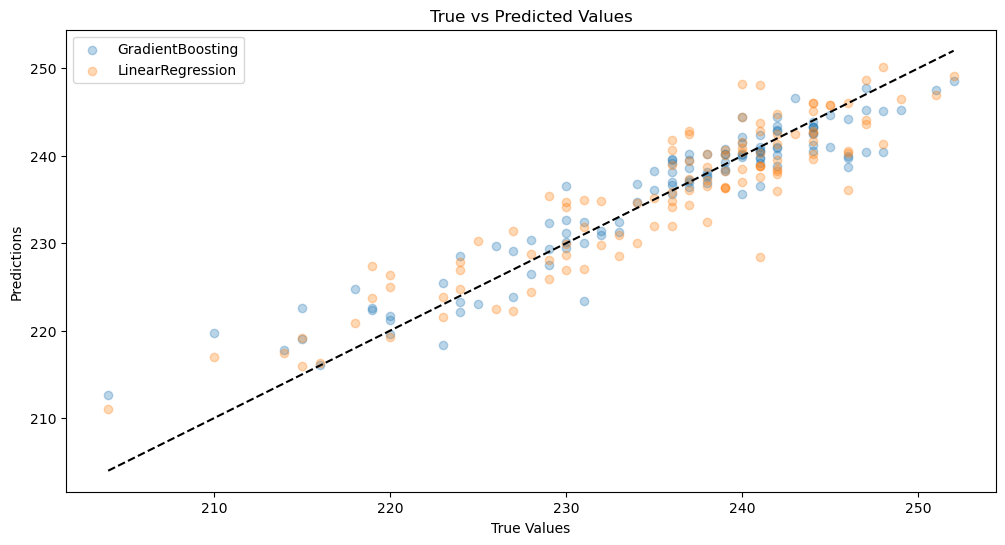

In [31]:
X_reg = data[features]
y_reg = data['G04_A_A_MATHEMATICS']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

# Пайплайн для линейной регрессии
pipe_lr_reg = Pipeline([
    ('prep', preprocessor),
    ('scale', StandardScaler(with_mean=False)),
    ('reg', LinearRegression())
])

# Пайплайн для градиентного бустинга (регрессия)
pipe_gb_reg = Pipeline([
    ('prep', preprocessor),
    ('reg', GradientBoostingRegressor(n_estimators=200, random_state=42))
])

# Обучение моделей
pipe_lr_reg.fit(X_train_r, y_train_r)
pipe_gb_reg.fit(X_train_r, y_train_r)

# Предсказания
y_pred_lr = pipe_lr_reg.predict(X_test_r)
y_pred_gb = pipe_gb_reg.predict(X_test_r)

# Метрики для регрессии
metrics_reg = pd.DataFrame({
    'Model': ['LinearRegression', 'GradientBoosting'],
    'MAE': [
        mean_absolute_error(y_test_r, y_pred_lr),
        mean_absolute_error(y_test_r, y_pred_gb)
    ],
    'MSE': [
        mean_squared_error(y_test_r, y_pred_lr),
        mean_squared_error(y_test_r, y_pred_gb)
    ],
    'RMSE': [
        root_mean_squared_error(y_test_r, y_pred_lr),
        root_mean_squared_error(y_test_r, y_pred_gb)
    ],
    'R2': [
        r2_score(y_test_r, y_pred_lr),
        r2_score(y_test_r, y_pred_gb)
    ]
}).set_index('Model')

print("Regression metrics:\n", metrics_reg)

# Дополнительно: визуализация предсказаний
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(y_test_r, y_pred_gb, alpha=0.3, label='GradientBoosting')
plt.scatter(y_test_r, y_pred_lr, alpha=0.3, label='LinearRegression')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'k--')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.legend()
plt.show()

## Обзор результатов

По результатам анализа моделей можно сделать вывод о том, что градиентный бустинг оказался более
подходящим решением в данной задаче по всем 4-м метрикам

Метрики были выбраны именно таким образом исходя из задачи (регрессия, а не классификация) и их смысла
для оценивания качества моделей
MAE - для оценки абсолютной ошибки, MSE - для более точной оценки ошибок (сильнее штрафует большие ошибки), RMSE - сохраняет свойства MSE,
но возращаемся к баллам, R2-score - для оценки качества модели

Следует отметить, что обе модели показали хорошие результаты в предсказании (R2-score > 0.8)